# Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from keras.applications import EfficientNetB0
from keras.applications.efficientnet import preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from keras.models import Model

# Load and Preprocess Images

In [5]:
IMG_SIZE = (224, 224)
IMAGE_DIR = Path("data/Images")

def load_and_preprocess(img_path: Path) -> np.ndarray:
    img = load_img(img_path, target_size=IMG_SIZE)   # PIL image
    arr = img_to_array(img)                           # shape: (224, 224, 3), values 0-255
    arr = preprocess_input(arr)                       
    return arr

# Collect all image paths
image_paths = sorted(IMAGE_DIR.glob("*.jpg"))
print(f"Total images found: {len(image_paths)}")

# Quick sanity check on one image
sample = load_and_preprocess(image_paths[0])
print(f"Sample shape: {sample.shape}")   # expected: (224, 224, 3)
print(f"Value range: [{sample.min():.2f}, {sample.max():.2f}]")  

Total images found: 8091
Sample shape: (224, 224, 3)
Value range: [0.00, 255.00]


# Build EfficientNetB0 Encoder

In [6]:
base_model = EfficientNetB0(
    include_top=False,       # remove classification head
    weights="imagenet",      # pretrained weights
    input_shape=(224, 224, 3),
    pooling="avg"            # global average pool -> 1280-dim vector
)

encoder = base_model  # output is already (None, 1280) with pooling=avg

encoder.summary()
print(f"\nOutput shape: {encoder.output_shape}")  

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)


Output shape: (None, 1280)


# Extract Feature Vectors

In [ ]:
BATCH_SIZE = 32  

def extract_features(paths: list, model: Model, batch_size: int) -> dict:
    features = {}
    total = len(paths)

    for i in range(0, total, batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_imgs = np.array([load_and_preprocess(p) for p in batch_paths])

        batch_features = model.predict(batch_imgs, verbose=0)  # (batch, 1280)

        for path, feat in zip(batch_paths, batch_features):
            features[path.name] = feat  

        print(f"Processed {min(i + batch_size, total)}/{total} images", end="\r")

    print("\nDone.")
    return features

features = extract_features(image_paths, encoder, BATCH_SIZE)
print(f"\nTotal feature vectors: {len(features)}")
print(f"Feature vector shape: {next(iter(features.values())).shape}") 

Processed 8091/8091 images
Done.

Total feature vectors: 8091
Feature vector shape: (1280,)


# Save Feature Vectors

In [8]:
SAVE_DIR = Path("outputs/encoder")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save features as .npy (one file per image, named by image filename)
FEATURES_DIR = SAVE_DIR / "features"
FEATURES_DIR.mkdir(exist_ok=True)

for img_name, feat_vec in features.items():
    save_path = FEATURES_DIR / (img_name.replace(".jpg", ".npy"))
    np.save(save_path, feat_vec)

# Also save all features in one combined dict file for convenience
np.save(SAVE_DIR / "all_features.npy", features)

# Save the encoder model
encoder.save(SAVE_DIR / "efficientnetb0_encoder.keras")

print(f"Saved {len(features)} feature files to: {FEATURES_DIR}")
print(f"Combined file saved: {SAVE_DIR / 'all_features.npy'}")
print(f"Model saved: {SAVE_DIR / 'efficientnetb0_encoder.keras'}")

Saved 8091 feature files to: outputs\encoder\features
Combined file saved: outputs\encoder\all_features.npy
Model saved: outputs\encoder\efficientnetb0_encoder.keras


# Verify Saved Features

In [9]:
loaded: dict = np.load(SAVE_DIR / "all_features.npy", allow_pickle=True).item()

print(f"Number of feature vectors loaded: {len(loaded)}")

for i, (name, vec) in enumerate(loaded.items()):
    print(f"  {name} -> shape: {vec.shape}, dtype: {vec.dtype}")
    if i == 4:
        print("  ...")
        break

# Check one individual .npy file
sample_file = list(FEATURES_DIR.glob("*.npy"))[0]
single = np.load(sample_file)
print(f"\nSingle file check: {sample_file.name} -> {single.shape}")

Number of feature vectors loaded: 8091
  1000268201_693b08cb0e.jpg -> shape: (1280,), dtype: float32
  1001773457_577c3a7d70.jpg -> shape: (1280,), dtype: float32
  1002674143_1b742ab4b8.jpg -> shape: (1280,), dtype: float32
  1003163366_44323f5815.jpg -> shape: (1280,), dtype: float32
  1007129816_e794419615.jpg -> shape: (1280,), dtype: float32
  ...

Single file check: 1000268201_693b08cb0e.npy -> (1280,)


#  Visualize Images with Feature Shapes

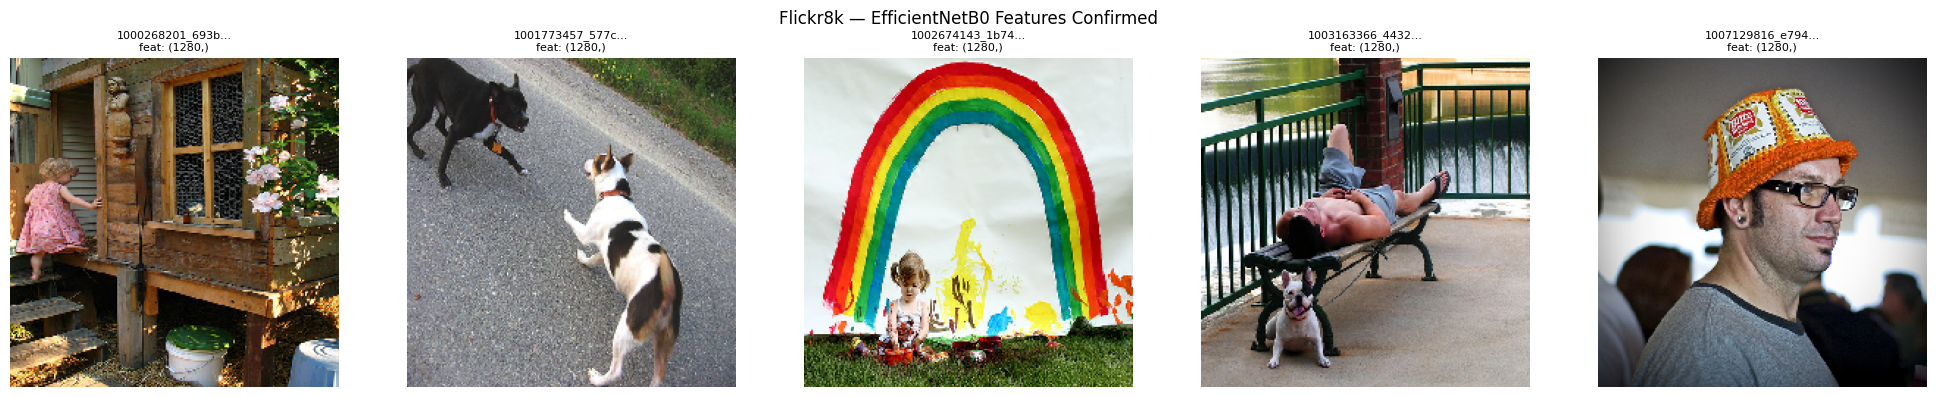

Visualization saved.


In [10]:
NUM_SAMPLES = 5
sample_paths = image_paths[:NUM_SAMPLES]

fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(20, 4))

for ax, path in zip(axes, sample_paths):
    img = load_img(path, target_size=IMG_SIZE)   # load original (no preprocess) for display
    feat_shape = loaded[path.name].shape

    ax.imshow(img)
    ax.set_title(f"{path.name[:15]}...\nfeat: {feat_shape}", fontsize=8)
    ax.axis("off")

plt.suptitle("Flickr8k — EfficientNetB0 Features Confirmed", fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR / "sample_verification.png", dpi=150)
plt.show()
print("Visualization saved.")